In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_pure   # NON-timemax, NON-phasemax
import parismc
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 12/12     # Total time

print(f"Using dt = {dt} seconds, T = {T} years")

inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0,
        "include_minus_m": False,
}

amplitude_kwargs = {
    "force_backend": force_backend
}

Ylm_kwargs = {
    "force_backend": force_backend,
}

sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1,6)
ell = 2

loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

print('Done initializing loglike class.')

data     = loglike_obj.signal
data_snr = float(gwf.rhostat(data))
print('SNR:', data_snr)

Using dt = 10 seconds, T = 1.0 years
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
SNR: 14.0812757390131


In [3]:

def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        print(loglike)
    return log_likes

In [4]:

def prior_transform(u):
    # hypercube 3sigma bounds
    logm1lim = [5.98699, 6.04277]
    logm2lim = [0.98935, 1.02067]
    alim = [0.67449, 0.78962]
    p0lim = [8.48613, 9.14781]
    e0lim = [0.38373, 0.40714]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

In [5]:

print('Done setting up log-likelihood and prior.')
print('Setting up ParisMC sampler...')

config = parismc.SamplerConfig(
    merge_confidence=0.9,
    alpha=int(1e3),
    trail_size=int(1e3),
    boundary_limiting=True,
    use_beta=True,
    integral_num=int(1e5),
    gamma=500,
    exclude_scale_z=np.inf,
    use_pool=False,
    keep_dead_processes=True
)
print('Done setting up ParisMC sampler.')
print('Setting up initial covariance matrix...')

ndim   = 5
n_seed = 75
init_cov      = np.eye(ndim) * 1e-2
init_cov_list = [init_cov] * n_seed

print('Done setting up initial covariance matrix.')
print('Initializing sampler...')

sampler = parismc.Sampler(
    ndim=ndim,
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
print('Done initializing sampler.')

print('Evaluating log_density on ellipse LHS points...')
import pickle

savepath = f'/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl'

with open(savepath, 'rb') as f:
    data = pickle.load(f)

external_lhs_points = data['lhs_u']
external_lhs_log_densities = data['log_densities']

def paris3_callback(sampler, i):
    if i % 1000 == 0 and i > 0:
        sampler.save_state()

Done setting up log-likelihood and prior.
Setting up ParisMC sampler...
Done setting up ParisMC sampler.
Setting up initial covariance matrix...
Done setting up initial covariance matrix.
Initializing sampler...
Done initializing sampler.
Evaluating log_density on ellipse LHS points...


In [6]:
lhs_pt = prior_transform(external_lhs_points[np.argmax(external_lhs_log_densities)].reshape(1,-1))
lhs_pt

array([[6.01448145, 1.00559501, 0.73051914, 8.82542906, 0.39504066]])

In [7]:
np.max(external_lhs_log_densities)

np.float64(2.6745468140742155)

In [ ]:

# print('Running paris3 sampling...')
# sampler.run_sampling(
#     num_iterations=int(100),
#     savepath='./intrinsic_ffunc_3mth_snr32_paris3_1yr_debug',
#     print_iter=100,
#     callback=paris3_callback,
#     external_lhs_points=external_lhs_points,
#     external_lhs_log_densities=external_lhs_log_densities,
#     stop_max_ld_stable_iters=int(1e4)
# )
# print('Done.')


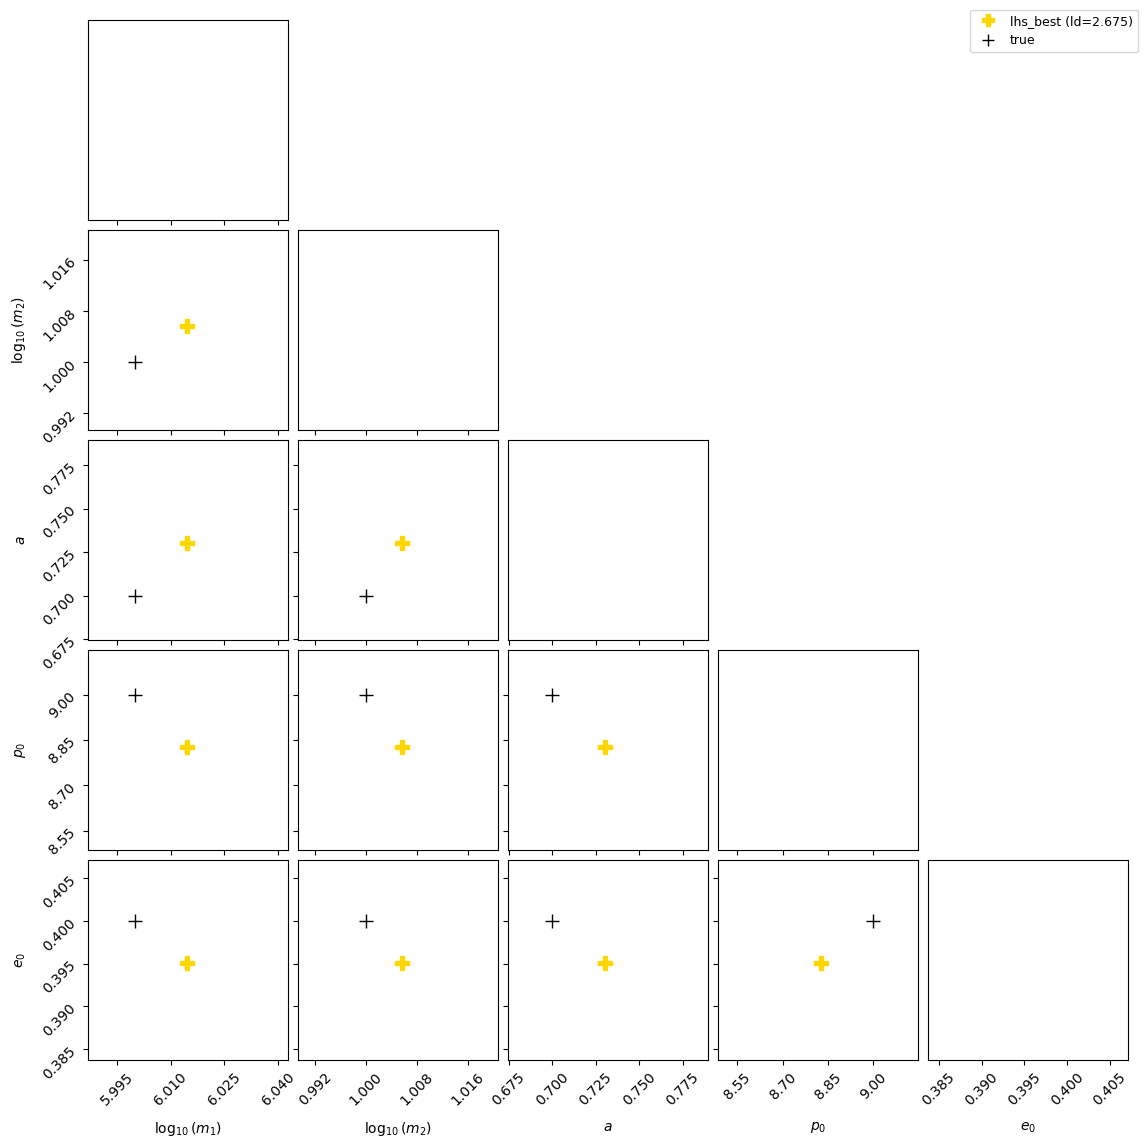

lhs_best: [6.01448 1.00559 0.73052 8.82543 0.39504]  logden=2.67455
true:     [6.  1.  0.7 9.  0.4]


In [8]:
import corner                                                                                                                                                                      
import pickle                                                                                                                                                                        
import numpy as np                                                                                                                                                                   
import matplotlib.pyplot as plt                                                                                                                                                      
from matplotlib.lines import Line2D                                                                                                                                                  
                                                                                                                                                                                    
with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl', 'rb') as f:                                                                     
    lhs_data = pickle.load(f)
                                                                                                                                                                                    
lhs_u      = lhs_data['lhs_u']
lhs_ld     = lhs_data['log_densities']                                                                                                                                               
ellipse_lo = lhs_data['ellipse_lo']
ellipse_hi = lhs_data['ellipse_hi']
                                                                                                                                                                                    
best_idx      = np.argmax(lhs_ld)
lhs_best_phys = ellipse_lo + (ellipse_hi - ellipse_lo) * lhs_u[best_idx]                                                                                                             
true_params   = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
                                                                                                                                                                                    
ndim   = 5
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                      
ranges = [(ellipse_lo[i], ellipse_hi[i]) for i in range(ndim)]                                                                                                                       

plot_points = {                                                                                                                                                                      
    'lhs_best': lhs_best_phys,
    'true':     true_params,                                                                                                                                                         
}
colors  = ['gold', 'black']                                                                                                                                                          
markers = ['P',    '+']
mlds    = [lhs_ld[best_idx], None]
                                                                                                                                                                                    
lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])                                                                                                                                                
mid = (lo + hi) / 2                                                                                                                                                                  
all_pts_padded = np.vstack([np.array(list(plot_points.values())), lo, hi, mid, (lo+mid)/2, (hi+mid)/2])                                                                                                                                                                                     
fig = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False,                                                                                                                       
                    plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))                                                                                                                                 

for (name, pt), c, mk in zip(plot_points.items(), colors, markers):                                                                                                                  
    corner.overplot_points(fig, pt.reshape(1, -1), color=c, marker=mk, ms=10)
                                                                                                                                                                                    
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):                                                                                                                                                              
    for col in range(ndim):
        if col <= row: axes[row, col].set_xlim(ranges[col])
        if col < row:  axes[row, col].set_ylim(ranges[row])                                                                                                                          

handles = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,                                                                                                                          
                label=f"{name} (ld={ld:.3f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points.items(), colors, markers, mlds)]                                                                                              
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()                                                                                                                                                                           
                
print(f'lhs_best: {np.round(lhs_best_phys, 5)}  logden={lhs_ld[best_idx]:.5f}')                                                                                                      
print(f'true:     {true_params}')

In [9]:
proc1_maxld_pt = lhs_pt.copy()
proc1_maxld_pt

array([[6.01448145, 1.00559501, 0.73051914, 8.82542906, 0.39504066]])

In [10]:
# connect two highest logden pts
#NOTE: change here for closest point vs max ld pt
# proc1_maxld_pt_1d = proc1_maxld_pt[0] 
proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [11]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


1.8137395988129634
-0.011867987890926088
-0.014153008215025777
0.9321640376959233
0.03469243028643421
-0.02290022877847891
0.3281109525638792
0.21585123242723803
-0.026275432742079004
-0.02111539088670944
0.3339554957710579
0.02393311734643713
-0.02797086277406257
-0.005118679158289728
0.06918220844289777
0.01779615884730236
-0.004569181745536751
-0.005442061128876191
-0.00224996103588805
-0.0036308074089820633
-0.0084205486020883
-0.01206597339791154
-0.012060259404094265
-0.00808659676884174
-0.0012643824453212277
0.005809765046088384
0.009893008710544684
0.008674289272696097
0.0017849242683001274
-0.008606584870165681
-0.01815881254921737
-0.023084232704485164
-0.021604367374863175
-0.007776832269670369
0.026849181528303928
0.04036893694988323
0.003062664758357212
-0.017637389670987175
-0.00849354919897482
0.018914417071909776
0.009222384303535877
-0.009542889800263287
-0.005280231245168799
0.013853557849153049
0.006175777792632389
-0.020289659469244183
0.05824945120002731
-0.007800

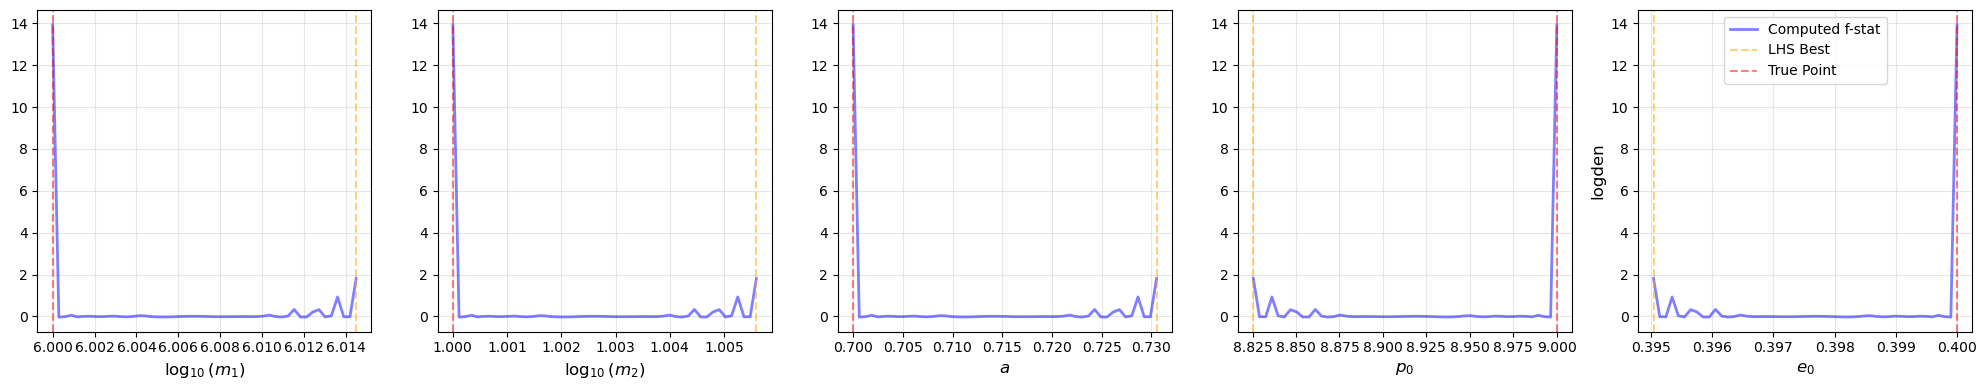

In [12]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'LHS Best')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [13]:
import loglike_phase                                                                                                                                                            
loglike_obj_pm = loglike_phase.LogLikePhase(                                                                                                                                  
    params_star, waveform_gen_comb, gwf, verbose=False,                                                                                                                         
    waveform_gen_sep=waveform_gen_sep, ell=ell, n_vals=n_vals, M_mode=None                                                                                                      
)                                                                                                                                                                               

In [14]:

def log_density_pm(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj_pm(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        # print(loglike)
    return log_likes

In [15]:
logden_theory_proc1_pm = []
logden_theory_proc1_pm.append(log_density_pm(np.array(line_points_proc1).T))
logden_theory_proc1_pm = np.array(logden_theory_proc1_pm).flatten()


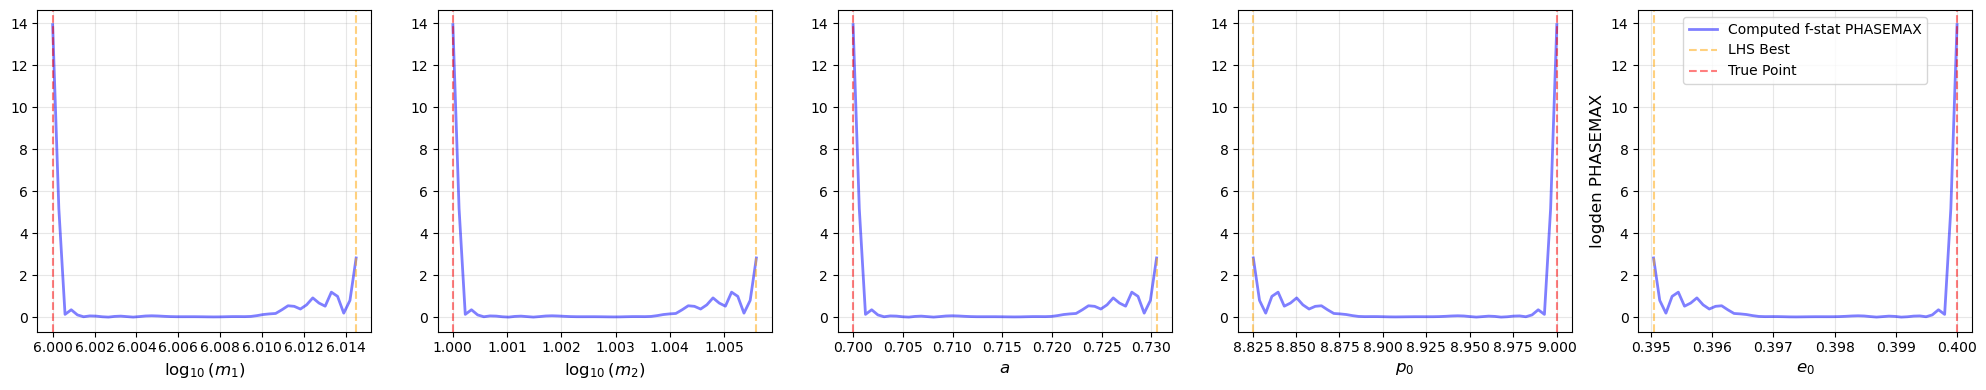

In [16]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden PHASEMAX', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_pm, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat PHASEMAX')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'LHS Best')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [17]:
import importlib                                                                                                                                                                
import GWfuncs                                                                                                                                                                  
importlib.reload(GWfuncs)                                                                                                                                                       
                                                                                                                                                                                
  # then rebuild gwf                                                                                                                                                              
gwf = GWfuncs.GravWaveAnalysis(T, dt)
import loglike_timeonly                                                                                                                                                         
loglike_obj_to = loglike_timeonly.LogLikeTimeOnly(                                                                                                                              
    params_star, waveform_gen_comb, gwf, verbose=False,                                                                                                                         
    waveform_gen_sep=waveform_gen_sep, ell=ell, n_vals=n_vals, M_mode=None                                                                                                      
) 

In [18]:

def log_density_to(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj_to(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        # print(loglike)
    return log_likes

In [19]:
logden_theory_proc1_to = []
logden_theory_proc1_to.append(log_density_to(np.array(line_points_proc1).T))
logden_theory_proc1_to = np.array(logden_theory_proc1_to).flatten()


In [20]:
logden_theory_proc1_to

array([ 3.44387568,  3.53349332,  3.99907885,  3.22163574,  3.56926888,
        3.92314937,  3.4722719 ,  3.22239898,  3.84486721,  4.08559219,
        3.73782712,  3.13090692,  3.71548847,  4.37989129,  4.58590853,
        4.35115431,  3.91173896,  3.49838034,  3.61905175,  4.04368888,
        4.31182117,  4.54575974,  4.68415615,  4.76595733,  4.87071198,
        4.90344013,  4.84153009,  4.79301389,  4.66695747,  4.46860067,
        4.86085452,  5.40437777,  5.88832589,  6.14006166,  6.0786615 ,
        5.58938799,  5.70037744,  7.27309102,  8.60976286,  8.69897138,
        7.00114357,  7.94311956, 11.11071012, 11.37522703,  7.3294409 ,
       10.09036444, 13.53627154,  9.56818142,  9.13910577, 13.93466256])

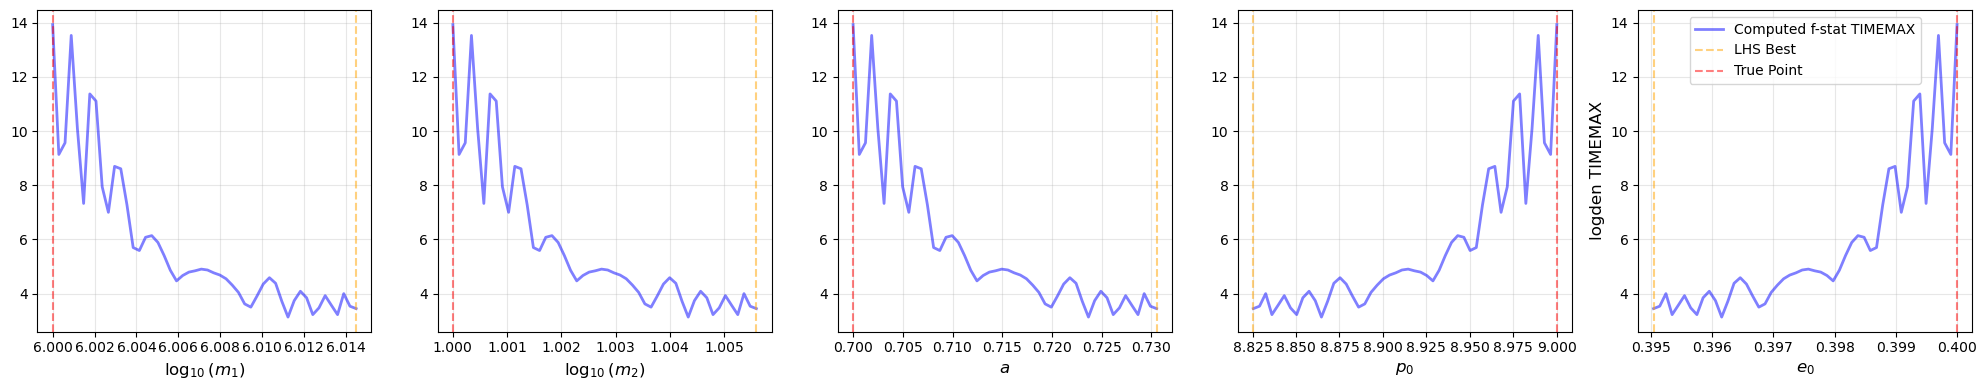

In [21]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden TIMEMAX', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_to, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat TIMEMAX')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'LHS Best')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:
import loglike_timemax                                                                                                                                                        
loglike_obj_tm = loglike_timemax.LogLikeTimeMax(                                                                                                                              
    params_star, waveform_gen_comb, gwf, verbose=False,                                                                                                                         
    waveform_gen_sep=waveform_gen_sep, ell=ell, n_vals=n_vals, M_mode=None                                                                                                      
) 

In [23]:

def log_density_tm(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj_tm(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        # print(loglike)
    return log_likes

In [24]:
logden_theory_proc1_tm = []
logden_theory_proc1_tm.append(log_density_tm(np.array(line_points_proc1).T))
logden_theory_proc1_tm = np.array(logden_theory_proc1_tm).flatten()


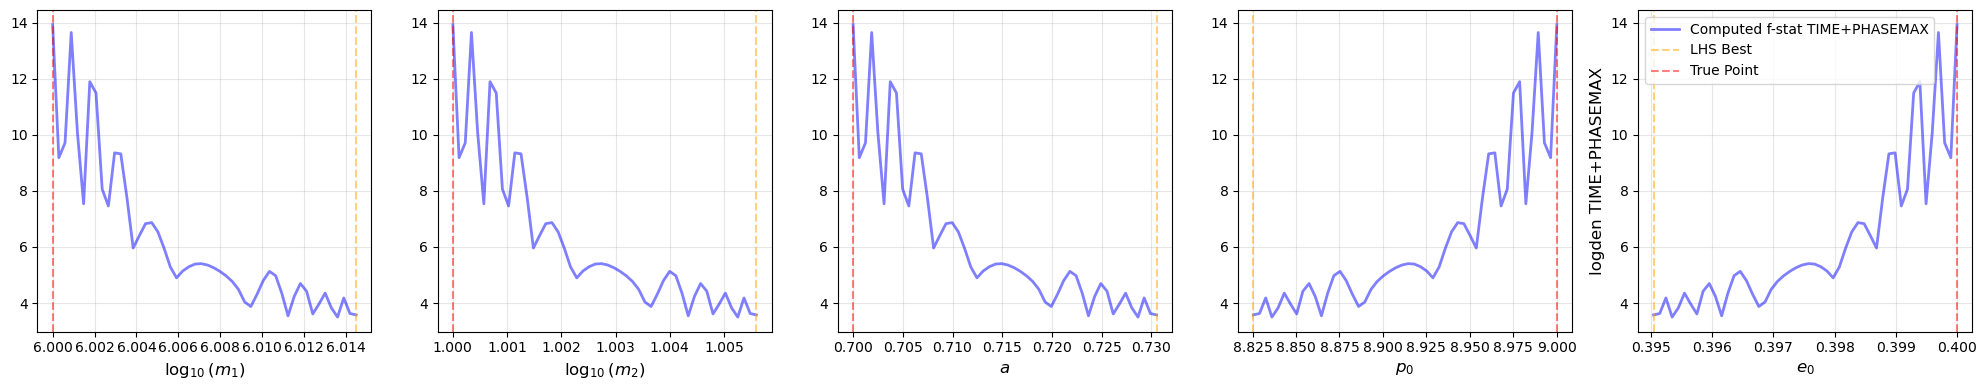

In [25]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden TIME+PHASEMAX', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_tm, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat TIME+PHASEMAX')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'LHS Best')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
